In [ ]:
from spyglass.common import Electrode, ElectrodeGroup
from spyglass.lfp.v1 import LFPV1
import spyglass.spikesorting.v0 as sgs
from spyglass.spikesorting.analysis.v1.group import (
    SortedSpikesGroup,
    SpikeSortingOutput,
)

import spyglass.common as sgc
import spyglass.lfp as lfp

[2026-04-27 08:39:56,756][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


In [ ]:
key = {"nwb_file_name": "wilbur20210404_.nwb"}
(sgs.SpikeSortingRecording & key) - "preproc_params_name LIKE '%tetrode%'"

query = SpikeSortingOutput.CuratedSpikeSorting & (SortedSpikesGroup.Units() & key).proj(
    merge_id="spikesorting_merge_id"
)

(sgs.SortGroup & query)
# (Electrode() & key) - "probe_id LIKE 'tetrode%'"

nwb_file_name name of the NWB file,sort_group_id identifier for a group of electrodes,"sort_reference_electrode_id the electrode to use for reference. -1: no reference, -2: common median"
wilbur20210404_.nwb,14,0
wilbur20210404_.nwb,15,0
wilbur20210404_.nwb,16,0
wilbur20210404_.nwb,17,0
wilbur20210404_.nwb,18,0
wilbur20210404_.nwb,19,0
wilbur20210404_.nwb,20,0
wilbur20210404_.nwb,21,0


In [4]:
lfp_electrode_ids = [128]
lfp_electrode_group_name = "sb_single_mpfc"
nwb_file_name = "wilbur20210404_.nwb"
lfp_eg_key = {
    **key,
    "lfp_electrode_group_name": lfp_electrode_group_name,
}

# lfp.lfp_electrode.LFPElectrodeGroup.create_lfp_electrode_group(
#     nwb_file_name=nwb_file_name,
#     group_name=lfp_electrode_group_name,
#     electrode_list=lfp_electrode_ids,
# )

In [ ]:
(
    lfp.lfp_electrode.LFPElectrodeGroup
    & {
        "nwb_file_name": nwb_file_name,
        "lfp_electrode_group_name": lfp_electrode_group_name,
    }
)

nwb_file_name name of the NWB file,lfp_electrode_group_name the name of this group of electrodes
wilbur20210404_.nwb,sb_single_mpfc


In [ ]:
hpc_entries = (
    lfp.v1.LFPSelection() & key & {"lfp_electrode_group_name": "lfp_tets_wilbur"}
)
hpc_entries

hpc_keys = hpc_entries.fetch(as_dict=True)

mpfc_entries = []
for k in hpc_keys:
    k["lfp_electrode_group_name"] = lfp_electrode_group_name
    mpfc_entries.append(k)

# lfp.v1.LFPSelection().insert(mpfc_entries, skip_duplicates=True)
LFPV1 & mpfc_entries

nwb_file_name name of the NWB file,lfp_electrode_group_name the name of this group of electrodes,target_interval_list_name descriptive name of this interval list,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,analysis_file_name name of the file,interval_list_name descriptive name of this interval list,lfp_object_id the NWB object ID for loading this object from the file,"lfp_sampling_rate the sampling rate, in HZ"
wilbur20210404_.nwb,sb_single_mpfc,01_s1,LFP 0-400 Hz,30000,wilbur20210404_JTMP2BWR9Q.nwb,lfp_sb_single_mpfc_01_s1_valid times,60c36350-472e-44e0-9dd1-2355feb1700e,1000.0
wilbur20210404_.nwb,sb_single_mpfc,02_r1 noPrePostTrialTimes,LFP 0-400 Hz,30000,wilbur20210404_UDOT6EYA2N.nwb,lfp_sb_single_mpfc_02_r1 noPrePostTrialTimes_valid times,76202b26-4cd5-477a-a621-5705486a9e34,1000.0
wilbur20210404_.nwb,sb_single_mpfc,03_s2,LFP 0-400 Hz,30000,wilbur20210404_99VGG0BK8O.nwb,lfp_sb_single_mpfc_03_s2_valid times,f1f10395-fb96-47be-8b0a-7a93b9c90ef1,1000.0
wilbur20210404_.nwb,sb_single_mpfc,04_r2 noPrePostTrialTimes,LFP 0-400 Hz,30000,wilbur20210404_49BRUBYLUN.nwb,lfp_sb_single_mpfc_04_r2 noPrePostTrialTimes_valid times,a587a3f8-ca26-4daa-9d47-d074671694cb,1000.0
wilbur20210404_.nwb,sb_single_mpfc,05_s3,LFP 0-400 Hz,30000,wilbur20210404_7DL2QG67IH.nwb,lfp_sb_single_mpfc_05_s3_valid times,301593e1-9895-45cd-8506-1ffb7928f740,1000.0
wilbur20210404_.nwb,sb_single_mpfc,06_r3 noPrePostTrialTimes,LFP 0-400 Hz,30000,wilbur20210404_FW9Z0UXBW5.nwb,lfp_sb_single_mpfc_06_r3 noPrePostTrialTimes_valid times,8b61bb5d-6bb6-4a6c-8b2b-3058e1dcf1c8,1000.0
wilbur20210404_.nwb,sb_single_mpfc,07_s4,LFP 0-400 Hz,30000,wilbur20210404_SWCNCIHZZ1.nwb,lfp_sb_single_mpfc_07_s4_valid times,647c0add-8e78-4c41-88f8-893826cf5af3,1000.0
wilbur20210404_.nwb,sb_single_mpfc,08_r4 noPrePostTrialTimes,LFP 0-400 Hz,30000,wilbur20210404_X05DMNWUT5.nwb,lfp_sb_single_mpfc_08_r4 noPrePostTrialTimes_valid times,2c9abfeb-7c1b-4a28-9db1-97c6d8b854cb,1000.0
wilbur20210404_.nwb,sb_single_mpfc,09_s5,LFP 0-400 Hz,30000,wilbur20210404_VXR3XOY94E.nwb,lfp_sb_single_mpfc_09_s5_valid times,fda6d4cb-e98a-4e34-8425-ecb285eb6015,1000.0
wilbur20210404_.nwb,sb_single_mpfc,10_r5 noPrePostTrialTimes,LFP 0-400 Hz,30000,wilbur20210404_X0B60BGCEW.nwb,lfp_sb_single_mpfc_10_r5 noPrePostTrialTimes_valid times,57e1eb9e-7419-4f88-af59-5318b3fa0975,1000.0


In [ ]:
from spyglass.lfp.lfp_merge import LFPOutput

merge_query = LFPOutput().LFPV1() & mpfc_entries
merge_query = merge_query.proj(lfp_merge_id="merge_id", *merge_query.heading.names)
merge_query

merge_id,lfp_merge_id,nwb_file_name name of the NWB file,lfp_electrode_group_name the name of this group of electrodes,target_interval_list_name descriptive name of this interval list,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter
00115cfb-3eb0-428f-cdd0-5630330489bf,00115cfb-3eb0-428f-cdd0-5630330489bf,wilbur20210404_.nwb,sb_single_mpfc,03_s2,LFP 0-400 Hz,30000
2155a0eb-ab83-e532-7cb4-17eecda6890f,2155a0eb-ab83-e532-7cb4-17eecda6890f,wilbur20210404_.nwb,sb_single_mpfc,02_r1 noPrePostTrialTimes,LFP 0-400 Hz,30000
46d688b0-26c5-d28f-2193-d1dcc7e9a9b6,46d688b0-26c5-d28f-2193-d1dcc7e9a9b6,wilbur20210404_.nwb,sb_single_mpfc,06_r3 noPrePostTrialTimes,LFP 0-400 Hz,30000
8b2cb398-b634-755b-1cb0-256dfc2cf297,8b2cb398-b634-755b-1cb0-256dfc2cf297,wilbur20210404_.nwb,sb_single_mpfc,10_r5 noPrePostTrialTimes,LFP 0-400 Hz,30000
8d9d5bbe-345c-0184-d81f-3f10be8290ed,8d9d5bbe-345c-0184-d81f-3f10be8290ed,wilbur20210404_.nwb,sb_single_mpfc,05_s3,LFP 0-400 Hz,30000
a04571c5-32cc-a614-a979-2857b075bf97,a04571c5-32cc-a614-a979-2857b075bf97,wilbur20210404_.nwb,sb_single_mpfc,08_r4 noPrePostTrialTimes,LFP 0-400 Hz,30000
a601bb14-5666-625c-b027-a8a5a6e72ef7,a601bb14-5666-625c-b027-a8a5a6e72ef7,wilbur20210404_.nwb,sb_single_mpfc,01_s1,LFP 0-400 Hz,30000
a811936e-5e42-f22f-eb55-fd7a890b0baa,a811936e-5e42-f22f-eb55-fd7a890b0baa,wilbur20210404_.nwb,sb_single_mpfc,07_s4,LFP 0-400 Hz,30000
c4301422-f763-405c-9088-e7ec90592c8d,c4301422-f763-405c-9088-e7ec90592c8d,wilbur20210404_.nwb,sb_single_mpfc,09_s5,LFP 0-400 Hz,30000
c4479a79-9792-cfac-21ec-f84c69cb3688,c4479a79-9792-cfac-21ec-f84c69cb3688,wilbur20210404_.nwb,sb_single_mpfc,04_r2 noPrePostTrialTimes,LFP 0-400 Hz,30000


In [ ]:
from spyglass.lfp.analysis.v1.lfp_band import LFPBandSelection, LFPBandV1

filter_name = "theta_5_11"


LFPBandSelection() & key & {"filter_name": filter_name}

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,min_interval_len the minimum length of a valid interval to filter


In [ ]:
to_pop = []
for key in merge_query.fetch(as_dict=True):
    key.pop("merge_id")
    key.pop("filter_name")
    key.pop("filter_sampling_rate")
    to_pop.append(key.copy())
    if LFPBandSelection & key:
        print(f"Already exists: {key}")
        continue

    # lfp_band_electrode_ids = [0]  # assumes we've filtered these electrodes
    lfp_band_sampling_rate = 100  # desired sampling rate

    LFPBandSelection().set_lfp_band_electrodes(
        nwb_file_name=nwb_file_name,
        lfp_merge_id=key["lfp_merge_id"],
        electrode_list=lfp_electrode_ids,
        filter_name=filter_name,  # defined above
        interval_list_name=key[
            "target_interval_list_name"
        ],  # Defined in IntervalList above
        reference_electrode_list=[-1],  # -1 means no ref electrode for all channels
        lfp_band_sampling_rate=lfp_band_sampling_rate,
    )

Already exists: {'lfp_merge_id': UUID('a601bb14-5666-625c-b027-a8a5a6e72ef7'), 'nwb_file_name': 'wilbur20210404_.nwb', 'lfp_electrode_group_name': 'sb_single_mpfc', 'target_interval_list_name': '01_s1'}
Already exists: {'lfp_merge_id': UUID('2155a0eb-ab83-e532-7cb4-17eecda6890f'), 'nwb_file_name': 'wilbur20210404_.nwb', 'lfp_electrode_group_name': 'sb_single_mpfc', 'target_interval_list_name': '02_r1 noPrePostTrialTimes'}
Already exists: {'lfp_merge_id': UUID('00115cfb-3eb0-428f-cdd0-5630330489bf'), 'nwb_file_name': 'wilbur20210404_.nwb', 'lfp_electrode_group_name': 'sb_single_mpfc', 'target_interval_list_name': '03_s2'}
Already exists: {'lfp_merge_id': UUID('c4479a79-9792-cfac-21ec-f84c69cb3688'), 'nwb_file_name': 'wilbur20210404_.nwb', 'lfp_electrode_group_name': 'sb_single_mpfc', 'target_interval_list_name': '04_r2 noPrePostTrialTimes'}
Already exists: {'lfp_merge_id': UUID('8d9d5bbe-345c-0184-d81f-3f10be8290ed'), 'nwb_file_name': 'wilbur20210404_.nwb', 'lfp_electrode_group_name': '

In [38]:
LFPBandSelection & to_pop

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,min_interval_len the minimum length of a valid interval to filter
00115cfb-3eb0-428f-cdd0-5630330489bf,theta_5_11,1000,wilbur20210404_.nwb,03_s2,100,1.0
2155a0eb-ab83-e532-7cb4-17eecda6890f,theta_5_11,1000,wilbur20210404_.nwb,02_r1 noPrePostTrialTimes,100,1.0
46d688b0-26c5-d28f-2193-d1dcc7e9a9b6,theta_5_11,1000,wilbur20210404_.nwb,06_r3 noPrePostTrialTimes,100,1.0
8b2cb398-b634-755b-1cb0-256dfc2cf297,theta_5_11,1000,wilbur20210404_.nwb,10_r5 noPrePostTrialTimes,100,1.0
8d9d5bbe-345c-0184-d81f-3f10be8290ed,theta_5_11,1000,wilbur20210404_.nwb,05_s3,100,1.0
a04571c5-32cc-a614-a979-2857b075bf97,theta_5_11,1000,wilbur20210404_.nwb,08_r4 noPrePostTrialTimes,100,1.0
a601bb14-5666-625c-b027-a8a5a6e72ef7,theta_5_11,1000,wilbur20210404_.nwb,01_s1,100,1.0
a811936e-5e42-f22f-eb55-fd7a890b0baa,theta_5_11,1000,wilbur20210404_.nwb,07_s4,100,1.0
c4301422-f763-405c-9088-e7ec90592c8d,theta_5_11,1000,wilbur20210404_.nwb,09_s5,100,1.0
c4479a79-9792-cfac-21ec-f84c69cb3688,theta_5_11,1000,wilbur20210404_.nwb,04_r2 noPrePostTrialTimes,100,1.0


In [39]:
LFPBandV1().populate(to_pop, processes=11)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_

[08:57:12][WARNING] Spyglass: Interval time warning: stop time larger than last timestamp, substituting last: 1617566619.1493478 < 1617566619.1483479
[08:57:12][WARNING] Spyglass: Interval time warning: stop time larger than last timestamp, substituting last: 1617572559.4486296 < 1617572559.4476295
[08:57:12][WARNING] Spyglass: Interval time warning: stop time larger than last timestamp, substituting last: 1617568707.5495365 < 1617568707.5485365
[08:57:12][WARNING] Spyglass: Interval time warning: stop time larger than last timestamp, substituting last: 1617564275.749972 < 1617564275.7489722
[08:57:12][WARNING] Spyglass: Interval time warning: stop time larger than last timestamp, substituting last: 1617574545.0494668 < 1617574545.048467
[08:57:12][WARNING] Spyglass: Interval time warning: stop time larger than last timestamp, substituting last: 1617560174.548854 < 1617560174.5478542
[08:57:12][WARNING] Spyglass: Interval time warning: stop time larger than last timestamp, substituting

{'success_count': 11, 'error_list': []}

In [62]:
band = LFPBandV1 & to_pop & {"target_interval_list_name": "02_r1 noPrePostTrialTimes"}
# df = band.fetch1_dataframe()

band
lfp = LFPV1() & to_pop & {"target_interval_list_name": "02_r1 noPrePostTrialTimes"}
lfp_df = lfp.fetch1_dataframe()

/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


<Axes: xlabel='time'>

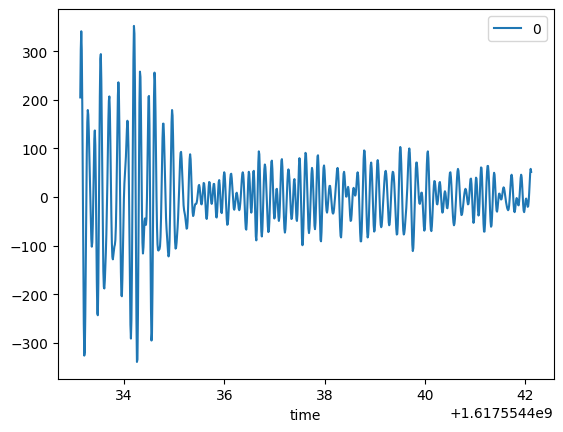

In [51]:
import matplotlib.pyplot as plt

df.iloc[100:1000].plot()

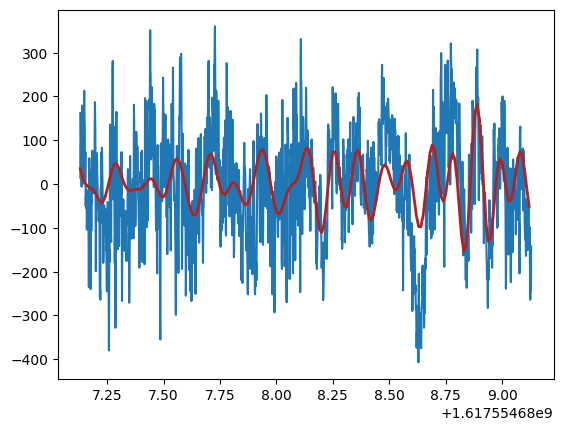

In [ ]:
st = 255000
ind = slice(st, st + 2000)
# lfp_df.iloc[ind].plot()
t = lfp_df.index[ind]
lfp = lfp_df.iloc[ind]
plt.plot(t, lfp)

ind_2 = slice(ind.start // 10, ind.stop // 10)
# df.iloc[ind_2].plot()
t = df.index[ind_2]
lfp = df.iloc[ind_2]
plt.plot(t, lfp, c="firebrick", lw=2)